# Rebuilding 2020 disturbance with Mackey et al. (2024) inputs

**Why this notebook exists.** Our 2015–2025 run (`outputs_v3`) reports less disturbance than Mackey et al.
for most ranges (Nipigon −29.9 points on the study-area boundary) and more for Sydney (+16.7).
That run replaced the paper's road and infrastructure layers with ECCC's 2020 footprint. Here we rebuild
2020 disturbance with the paper's own Ontario sources, keep every component separate, and measure which one
explains the gap. `outputs_v3` is not modified.

| Component | Paper's Ontario source | Here | Buffer |
|---|---|---|---|
| Harvest since 1980 | Ontario FRI + national modelled harvest | ARI 2025 harvest (1980–2020) ∪ national harvest 1985–2020 | 500 m |
| Roads | MNRF Road Segments + National Road Network | same two datasets, kept separate | 500 m |
| Mining, infrastructure, agriculture, rural | Ontario Land Cover Compilation v2 | OLCC v2 classes 25, 27, 28 | 500 m |
| Unclassified polygons | FRI `POLYTYPE` unclassified | ARI `POLYTYPE = 'UCL'` | 500 m |
| Fire since 1980 | National Fire Database polygons | NFDB polygons, `YEAR` 1980–2020 | none |

Downloads are documented in `data/raw/DATA_MANIFEST.md` (folder `data/raw/paper_inputs/`).
Set the environment variable `MACKEY_RANGES=Sydney` to test one range before a full run.

In [1]:
import os
import time
import warnings
from pathlib import Path

import cv2
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyogrio
import rasterio
from rasterio.features import rasterize
from rasterio.vrt import WarpedVRT
from rasterio.windows import from_bounds
from shapely.geometry import box

warnings.filterwarnings('ignore')

MARKER = Path('data') / 'Caribou_range_boundary' / 'Caribou_range_boundary.shp'
ROOT = next(c for c in [Path.cwd(), *Path.cwd().parents] if (c / MARKER).exists())
DATA, RAW = ROOT / 'data', ROOT / 'data' / 'raw'
PI = RAW / 'paper_inputs'
V3 = ROOT / 'outputs_v3'
OUT = ROOT / 'outputs_mackey_rebuild'
for sub in ['rasters', 'stats', 'figures']:
    (OUT / sub).mkdir(parents=True, exist_ok=True)

ARI_GDB = DATA / 'ARI_AnalysisReadyInventory2025' / 'ARI_AnalysisReadyInventory2025' / 'ARI_wFU.gdb'
ARI_EVENTS = DATA / 'interim' / 'ari_events_gdb'
NATIONAL_HARVEST = RAW / 'national_harvest' / 'CA_Forest_Harvest_1985-2022' / 'CA_Forest_Harvest_1985-2022.tif'
MNRF_ROADS = PI / 'mnrf_roads' / 'Non_Sensitive.gdb'
NRN_GPKG = next((PI / 'nrn_ontario').rglob('NRN_ON_*_GPKG_en.gpkg'))
NFDB = PI / 'nfdb_fire' / 'NFDB_poly_1972to2020_20250630.shp'
OLCC = next((PI / 'olcc_v2').rglob('OLCC_V2_TIFF.tif'))
ECCC_DIR = RAW / 'disturbance_2020'

YEAR = 2020
HARVEST_START = FIRE_START = 1980
BUFFER_M, RES_M, PIXEL_HA = 500, 30, 0.09
OLCC_CLASSES = [25, 27, 28]   # extraction / mining, community / infrastructure, agriculture and undifferentiated rural
PAPER_RANGES = ['Berens', 'Brightsand', 'Churchill', 'Kesagami', 'Nipigon', 'Pagwachuan', 'Sydney']
RUN = [r.strip() for r in os.environ.get('MACKEY_RANGES', ','.join(PAPER_RANGES)).split(',') if r.strip()]
PAPER = {'Berens': 46.4, 'Brightsand': 65.6, 'Churchill': 49.0, 'Kesagami': 53.5,
         'Nipigon': 74.4, 'Pagwachuan': 67.8, 'Sydney': 50.0}   # Table 4, % of range disturbed

# one bit per component in the saved flag raster
BITS = {'harvest': 0, 'roads_mnrf': 1, 'roads_nrn': 2, 'olcc': 3, 'fri_ucl': 4, 'fire': 5, 'eccc': 6, 'v3': 7}
PAPER_COMPONENTS = ['harvest', 'roads_mnrf', 'roads_nrn', 'olcc', 'fri_ucl', 'fire']
for p in [ARI_GDB, ARI_EVENTS, NATIONAL_HARVEST, MNRF_ROADS, NRN_GPKG, NFDB, OLCC]:
    assert p.exists(), p
print('root', ROOT)
print('ranges to run', RUN)

root <project root>
ranges to run ['Berens', 'Brightsand', 'Churchill', 'Kesagami', 'Nipigon', 'Pagwachuan', 'Sydney']


## 1. Ranges and the paper's study-area boundary
Range ∩ Area of Undertaking reproduced the paper's range areas within 2% in the v3 run.

In [2]:
ranges = gpd.read_file(DATA / 'Caribou_range_boundary' / 'Caribou_range_boundary.shp').to_crs(3978)
ranges = ranges[ranges.RANGE_NAME.isin(PAPER_RANGES)].set_index('RANGE_NAME')
bnd = gpd.read_file(ARI_GDB, layer='_FMU_FN_PARK_Boundary_simp2m').to_crs(3978)
bnd['geometry'] = bnd.geometry.make_valid()
STUDY_AREA = bnd.loc[bnd.TYPE == 'MU'].geometry.union_all()
eccc_files = {p.stem.split('_')[-1]: p for p in ECCC_DIR.glob('eccc_2020_total_disturbance_*.geojson')}
available_layers = {n for n, _ in pyogrio.list_layers(ARI_GDB)}
print(len(ranges), 'ranges; study area %.1f M ha' % (STUDY_AREA.area / 1e10))

7 ranges; study area 44.1 M ha


## 2. Helpers
Every layer is burned onto the range's own 30 m grid (the v3 potential-habitat grid), so all rasters align pixel for pixel.

In [3]:
def burn(geoms, profile, touched=False):
    shapes = [(g, 1) for g in geoms if g is not None and not g.is_empty]
    if not shapes:
        return np.zeros((profile['height'], profile['width']), bool)
    return rasterize(shapes, out_shape=(profile['height'], profile['width']), transform=profile['transform'],
                     fill=0, dtype='uint8', all_touched=touched).astype(bool)

def buffer_metres(mask, metres=BUFFER_M):
    if not mask.any():
        return mask
    dist = cv2.distanceTransform((~mask).astype('uint8'), cv2.DIST_L2, cv2.DIST_MASK_PRECISE)
    return dist * RES_M <= metres

def read_bbox(path, geom_3978, layer=None, columns=None, where=None):
    info = pyogrio.read_info(path, layer=layer)
    src_crs = info['crs'] or 'EPSG:4326'
    bb = gpd.GeoSeries([geom_3978], crs=3978).to_crs(src_crs).total_bounds
    df = pyogrio.read_dataframe(path, layer=layer, columns=columns, bbox=tuple(bb), where=where)
    if df.crs is None:
        df = df.set_crs(src_crs)
    return df.to_crs(3978)

def km_inside(lines, area_geom):
    if lines.empty:
        return 0.0
    return float(lines.geometry.intersection(area_geom).length.sum()) / 1000

## 3. Build every component for each range
Saves one `uint8` flag raster per range (bit per component: harvest, MNRF roads, NRN roads, OLCC, FRI unclassified, fire, ECCC footprint, v3 disturbance). Pixels outside the range are 0; mask with the potential-habitat raster.

In [4]:
rows, road_rows = [], []
t0 = time.time()
for name in RUN:
    rg = ranges.loc[name].geometry
    key = name.lower()
    with rasterio.open(next((V3 / '01_potential_habitat').glob(key + '_*.tif'))) as s:
        profile = s.profile.copy()
        valid = s.read(1) != 255
    bounds = rasterio.transform.array_bounds(profile['height'], profile['width'], profile['transform'])
    frame = box(*bounds)
    study = burn([STUDY_AREA.intersection(rg)], profile) & valid
    comp = {}

    # harvest since 1980: ARI year where ARI mapped a harvest, national year elsewhere (paper's precedence)
    ev = gpd.read_file(ARI_EVENTS / (key + '_ari_events.gpkg'))
    hv = ev[(ev.DEPTYPE == 'HARVEST') & ev.YRDEP.between(HARVEST_START, YEAR)]
    ari_h = burn(hv.geometry, profile)
    with rasterio.open(NATIONAL_HARVEST) as s:
        nat = s.read(1, window=from_bounds(*bounds, transform=s.transform).round_offsets().round_lengths())
    assert nat.shape == valid.shape, nat.shape
    comp['harvest'] = buffer_metres(ari_h | ((nat >= 1985) & (nat <= YEAR)))

    # roads
    mnrf = read_bbox(MNRF_ROADS, frame, layer='MNRF_ROAD_SEGMENT', columns=['YEAR_CONSTRUCTED', 'STATUS'])
    comp['roads_mnrf'] = buffer_metres(burn(mnrf.geometry, profile, touched=True))
    yc = pd.to_numeric(mnrf.YEAR_CONSTRUCTED, errors='coerce')
    mnrf_le = mnrf[~yc.between(YEAR + 1, 2100)]            # drop roads with a known construction year after 2020
    roads_mnrf_le2020 = buffer_metres(burn(mnrf_le.geometry, profile, touched=True))
    nrn = read_bbox(NRN_GPKG, frame, layer=next(n for n, _ in pyogrio.list_layers(NRN_GPKG) if n.endswith('ROADSEG')), columns=[])
    comp['roads_nrn'] = buffer_metres(burn(nrn.geometry, profile, touched=True))

    # OLCC v2 classes 25, 27, 28, warped from 15 m EPSG:3161 onto the 30 m grid (nearest)
    with rasterio.open(OLCC) as s, WarpedVRT(s, crs=profile['crs'], transform=profile['transform'], width=profile['width'],
                                             height=profile['height'], resampling=rasterio.enums.Resampling.nearest) as v:
        olcc = v.read(1)
    comp['olcc'] = buffer_metres(np.isin(olcc, OLCC_CLASSES) & valid)
    olcc_counts = {c: int((olcc[valid] == c).sum()) for c in OLCC_CLASSES}

    # FRI / ARI unclassified polygons
    hits = bnd[bnd.intersects(rg)]
    ucl = []
    for lyr in [n for n in hits.INV_NAME.dropna().unique() if n in available_layers]:
        g = read_bbox(ARI_GDB, frame, layer=lyr, columns=['POLYTYPE'], where="POLYTYPE = 'UCL'")
        if len(g):
            ucl.append(g)
    ucl = pd.concat(ucl) if ucl else gpd.GeoDataFrame(geometry=[], crs=3978)
    comp['fri_ucl'] = buffer_metres(burn(ucl.geometry, profile))

    # fire since 1980, National Fire Database, not buffered
    fire = read_bbox(NFDB, frame, columns=['YEAR', 'SRC_AGENCY'])
    fire = fire[pd.to_numeric(fire.YEAR, errors='coerce').between(FIRE_START, YEAR)]
    comp['fire'] = burn(fire.geometry.buffer(0), profile)

    # comparison layers
    fp = gpd.read_file(eccc_files[name]).set_crs(3978, allow_override=True)
    comp['eccc'] = burn(fp.geometry.buffer(0), profile)
    with rasterio.open(next((V3 / '02_disturbance').glob(key + f'_*{YEAR}.tif'))) as s:
        comp['v3'] = s.read(1) == 1

    for k in comp:
        comp[k] &= valid
    flags = np.zeros(valid.shape, np.uint8)
    for k, b in BITS.items():
        flags |= (comp[k].astype(np.uint8) << b)
    prof = profile.copy(); prof.update(dtype='uint8', nodata=None, compress='LZW', count=1)
    with rasterio.open(OUT / 'rasters' / f'{key}_disturbance_components_{YEAR}.tif', 'w', **prof) as dst:
        dst.write(flags, 1)
        dst.update_tags(bits=str(BITS), note='0 outside range; mask with 01_potential_habitat != 255')

    rebuild = np.zeros(valid.shape, bool)
    for k in PAPER_COMPONENTS:
        rebuild |= comp[k]
    rebuild_le = (rebuild & ~comp['roads_mnrf']) | roads_mnrf_le2020
    for zone, mask in [('full_range', valid), ('study_area', study)]:
        n = mask.sum()
        pct = lambda m: 100 * (m & mask).sum() / n
        row = dict(range=name, zone=zone, area_ha=n * PIXEL_HA, paper=PAPER[name],
                   v3=pct(comp['v3']), eccc_only=pct(comp['eccc']), rebuild=pct(rebuild),
                   rebuild_roads_le2020=pct(rebuild_le),
                   both=pct(rebuild & comp['v3']), rebuild_not_v3=pct(rebuild & ~comp['v3']), v3_not_rebuild=pct(comp['v3'] & ~rebuild))
        for k in PAPER_COMPONENTS:
            others = np.zeros(valid.shape, bool)
            for j in PAPER_COMPONENTS:
                if j != k:
                    others |= comp[j]
            row[f'alone_{k}'] = pct(comp[k])
            row[f'unique_{k}'] = pct(comp[k] & ~others)
            row[f'drop_without_{k}'] = row['rebuild'] - pct(others)
        rows.append(row)
    study_geom = STUDY_AREA.intersection(rg)
    road_rows.append(dict(range=name, study_km2=study_geom.area / 1e6,
                          mnrf_km=km_inside(mnrf, study_geom), nrn_km=km_inside(nrn, study_geom),
                          nfdb_fires_1980_2020=len(fire), ucl_polygons=len(ucl), **{f'olcc_{c}_px': v for c, v in olcc_counts.items()}))
    print(f'[{time.time() - t0:6.0f}s] {name} (study area): paper {PAPER[name]:.1f}% | v3 {rows[-1]["v3"]:.1f}% | rebuild {rows[-1]["rebuild"]:.1f}%', flush=True)
    del comp, flags, rebuild, rebuild_le, olcc, nat, ari_h

stats = pd.DataFrame(rows)
roads = pd.DataFrame(road_rows)
roads['mnrf_km_per_km2'] = roads.mnrf_km / roads.study_km2
roads['nrn_km_per_km2'] = roads.nrn_km / roads.study_km2
suffix = '' if set(RUN) == set(PAPER_RANGES) else '_' + '_'.join(r.lower() for r in RUN)
stats.to_csv(OUT / 'stats' / f'rebuild_components_{YEAR}{suffix}.csv', index=False)
roads.to_csv(OUT / 'stats' / f'road_density_and_inputs_{YEAR}{suffix}.csv', index=False)

[   293s] Berens (study area): paper 46.4% | v3 39.1% | rebuild 39.5%


[   709s] Brightsand (study area): paper 65.6% | v3 60.8% | rebuild 61.3%


[  1332s] Churchill (study area): paper 49.0% | v3 43.1% | rebuild 44.8%


[  2248s] Kesagami (study area): paper 53.5% | v3 56.7% | rebuild 53.2%


[  3390s] Nipigon (study area): paper 74.4% | v3 44.5% | rebuild 48.9%


[  4072s] Pagwachuan (study area): paper 67.8% | v3 64.1% | rebuild 68.1%


[  4112s] Sydney (study area): paper 50.0% | v3 66.7% | rebuild 68.8%


## 4. How close is the rebuild to the paper?
Study-area boundary, the paper's own basis. `rebuild_roads_le2020` drops MNRF roads with a known construction year after 2020 (the road layers are current, not 2020).

In [5]:
s = stats[stats.zone == 'study_area'].set_index('range')
cmp_ = s[['paper', 'v3', 'rebuild', 'rebuild_roads_le2020']].copy()
cmp_['gap_v3'] = cmp_.v3 - cmp_.paper
cmp_['gap_rebuild'] = cmp_.rebuild - cmp_.paper
cmp_['gap_rebuild_le2020'] = cmp_.rebuild_roads_le2020 - cmp_.paper
print('mean absolute gap: v3 %.1f | rebuild %.1f | rebuild (roads <= 2020) %.1f points'
      % (cmp_.gap_v3.abs().mean(), cmp_.gap_rebuild.abs().mean(), cmp_.gap_rebuild_le2020.abs().mean()))
cmp_.round(1)

mean absolute gap: v3 10.2 | rebuild 8.6 | rebuild (roads <= 2020) 9.5 points


,paper,v3,rebuild,rebuild_roads_le2020,gap_v3,gap_rebuild,gap_rebuild_le2020
range,,,,,,,
Berens,46.4,39.1,39.5,39.0,-7.3,-6.9,-7.4
Brightsand,65.6,60.8,61.3,59.5,-4.8,-4.3,-6.1
Churchill,49.0,43.1,44.8,42.8,-5.9,-4.2,-6.2
Kesagami,53.5,56.7,53.2,52.9,3.2,-0.3,-0.6
Nipigon,74.4,44.5,48.9,47.5,-29.9,-25.5,-26.9
Pagwachuan,67.8,64.1,68.1,66.1,-3.7,0.3,-1.7
Sydney,50.0,66.7,68.8,67.7,16.7,18.8,17.7


## 5. Which component carries the disturbance?
`alone_*` = share of the study area that component covers by itself; `unique_*` = covered by that component and no other; `drop_without_*` = how many points the rebuild loses if the component is removed.

In [6]:
cols = [c for c in s.columns if c.startswith(('alone_', 'unique_', 'drop_without_'))]
s[cols].round(1).T

range,Berens,Brightsand,Churchill,Kesagami,Nipigon,Pagwachuan,Sydney
alone_harvest,14.0,45.2,34.0,43.8,35.5,56.4,43.1
unique_harvest,4.5,10.4,6.4,9.7,6.2,9.0,10.1
drop_without_harvest,4.5,10.4,6.4,9.7,6.2,9.0,10.1
alone_roads_mnrf,10.0,33.5,30.6,38.2,36.4,57.8,36.5
unique_roads_mnrf,0.7,1.7,3.3,2.3,6.6,8.0,1.9
drop_without_roads_mnrf,0.7,1.7,3.3,2.3,6.6,8.0,1.9
alone_roads_nrn,2.6,15.3,12.0,11.9,9.3,12.5,8.8
unique_roads_nrn,0.1,0.0,0.0,0.0,0.0,0.0,0.0
drop_without_roads_nrn,0.1,0.0,0.0,0.0,0.0,0.0,0.0
alone_olcc,1.0,14.0,11.9,25.8,9.6,12.1,1.8


## 6. What does v3 miss, and what does it add?
Pixel agreement between the v3 2020 disturbance and the rebuild, as % of the study area.

In [7]:
s[['both', 'rebuild_not_v3', 'v3_not_rebuild', 'eccc_only']].round(1)

,both,rebuild_not_v3,v3_not_rebuild,eccc_only
range,,,,
Berens,37.6,1.9,1.5,34.0
Brightsand,56.6,4.7,4.2,43.3
Churchill,40.9,3.9,2.1,37.2
Kesagami,51.1,2.1,5.5,54.1
Nipigon,43.3,5.6,1.2,39.1
Pagwachuan,62.6,5.5,1.5,58.9
Sydney,65.2,3.7,1.5,50.0


## 7. Road density and input counts inside the study area

In [8]:
roads.set_index('range').round(3)

,study_km2,mnrf_km,nrn_km,nfdb_fires_1980_2020,ucl_polygons,olcc_25_px,olcc_27_px,olcc_28_px,mnrf_km_per_km2,nrn_km_per_km2
range,,,,,,,,,,
Berens,15821.951,2722.875,414.506,279,3892,81,8302,0,0.172,0.026
Brightsand,15133.898,8466.652,3189.516,108,5799,83,145185,1,0.559,0.211
Churchill,20100.044,10486.744,3581.807,60,12950,276,166016,0,0.522,0.178
Kesagami,33602.486,20732.703,4322.469,123,9740,18923,306978,154535,0.617,0.129
Nipigon,28971.473,19417.185,3026.270,160,13455,3036,162718,0,0.670,0.104
Pagwachuan,21509.303,24070.118,2762.038,79,13637,6489,118172,0,1.119,0.128
Sydney,5715.488,3622.486,556.682,55,2955,18751,13515,0,0.634,0.097


## 8. Figure: paper, v3 and rebuild

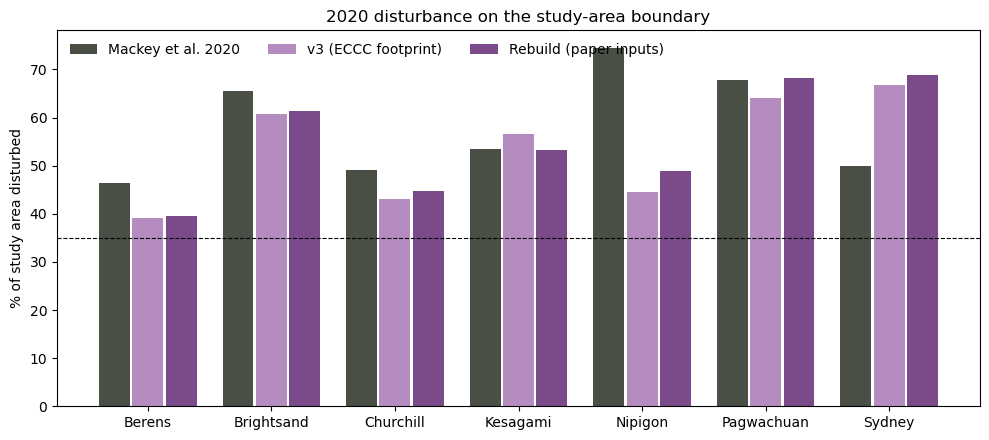

In [9]:
fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(cmp_))
for i, (col, lab, colr) in enumerate([('paper', 'Mackey et al. 2020', '#4a4f45'), ('v3', 'v3 (ECCC footprint)', '#b58cbf'),
                                       ('rebuild', 'Rebuild (paper inputs)', '#7b4a8a')]):
    ax.bar(x + (i - 1) * 0.27, cmp_[col], 0.25, label=lab, color=colr)
ax.axhline(35, color='k', ls='--', lw=0.8)
ax.set_xticks(x); ax.set_xticklabels(cmp_.index)
ax.set_ylabel('% of study area disturbed'); ax.legend(frameon=False, ncol=3, loc='upper left')
ax.set_title('2020 disturbance on the study-area boundary')
fig.tight_layout(); fig.savefig(OUT / 'figures' / f'paper_v3_rebuild_{YEAR}{suffix}.png', dpi=200)
plt.show()